In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions


CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion-AE/'
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()

print('Current working directory is:', '\n', notebook_path)

%load_ext autoreload
%autoreload 2

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion-AE


In [2]:
import os
import h5py
import torch
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader

In [3]:
from templates import *
device = 'cuda:0'
conf = ffhq256_autoenc()
# print(conf.name)
model = LitModel(conf)
state = torch.load(f'checkpoints/{conf.name}/last.ckpt', map_location='cpu')
model.load_state_dict(state['state_dict'], strict=False)
model.ema_model.eval()
model.ema_model.to(device)

Seed set to 0


Model params: 160.69 M


BeatGANsAutoencModel(
  (time_embed): TimeStyleSeperateEmbed(
    (time_embed): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
    (style): Identity()
  )
  (input_blocks): ModuleList(
    (0): TimestepEmbedSequential(
      (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1-2): 2 x TimestepEmbedSequential(
      (0): ResBlock(
        (in_layers): Sequential(
          (0): GroupNorm32(32, 128, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (h_upd): Identity()
        (x_upd): Identity()
        (emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=256, bias=True)
        )
        (cond_emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=128, bias

In [22]:
def get_dataloaders(args):
    """Initialize and return train and validation dataloaders."""
    train_dataset = LatentDataset(
        "datasets/encoded_latents_ffhq/encoded_ffhq_train_bg.h5",
        "datasets/encoded_latents_ffhq/encoded_ffhq_train_glass.h5"
    )

    val_dataset = LatentDataset(
        "datasets/encoded_latents_ffhq/encoded_ffhq_test_bg.h5",
        "datasets/encoded_latents_ffhq/encoded_ffhq_test_glass.h5"
    )

    train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, pin_memory=True)
    val_dataloader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False, pin_memory=True)
    test_batch = next(iter(val_dataloader))

    return train_dataloader, val_dataloader, test_batch


def get_fixed_for_test(test_batch, image_data_dir, diffAE_model, device):
    """Extracts test images and corresponding latent vectors."""
    # Extract the first sample from the batch
    diffAE_zbg = test_batch["diffAE_zbg"][1].unsqueeze(0).to(device)  # Background latent vector
    diffAE_zt = test_batch["diffAE_zt"][1].unsqueeze(0).to(device)  # Transformed latent vector

    filename_bg = test_batch["filename_bg"][1]
    filename_t = test_batch["filename_t"][1]
    
    # Construct image paths
    #dataset_path = /home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/ffhq_cs
    image_path_bg = f"{image_data_dir}/test_bg/{filename_bg}"
    image_path_t = f"{image_data_dir}/test_glass/{filename_t}"

    # Load images using SingleImageDataset
    data_bg = SingleImageDataset(image_path_bg, do_augment=False, image_size=256)
    data_t = SingleImageDataset(image_path_t, do_augment=False, image_size=256)

    image_bg = data_bg[1]  # Get preprocessed image
    image_t = data_t[1]  

    ori_img_bg = image_bg["img"][None].to(device) 
    ori_img_t = image_t["img"][None].to(device) 

    xT_bg = diffAE_model.encode_stochastic(ori_img_bg, diffAE_zbg, T=250)
    xT_t = diffAE_model.encode_stochastic(ori_img_t, diffAE_zt, T=250)


    return ori_img_bg, ori_img_t, diffAE_zbg, diffAE_zt, xT_bg, xT_t

In [5]:
# for batch in train_dataloader:  # Iterate over batches
#     diffAE_Zbg = batch["diffAE_zbg"].to(device, non_blocking=True)
#     diffAE_Zt = batch["diffAE_zt"].to(device, non_blocking=True)
#     filename_bg = batch["filename_bg"]
#     filename_t = batch["filename_t"]

#     break

In [6]:
import argparse
# Create a test args object
args = argparse.Namespace()
args.batch_size = 4
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [23]:
image_data_dir = "/home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/ffhq_cs"
train_dataloader, val_dataloader, test_batch = get_dataloaders(args)
ori_img_bg, ori_img_t, diffAE_zbg, diffAE_zt, xT_bg, xT_t = get_fixed_for_test(test_batch, image_data_dir, model, device)

In [ ]:
import torch
import matplotlib.pyplot as plt

def show_image_results(ori_img_bg, ori_img_t, diffAE_zbg, diffAE_zt, xT_bg, xT_t):
    ori_bg = ((ori_img_bg + 1) / 2).cpu().detach().numpy()
    ori_t = ((ori_img_t + 1) / 2).cpu().detach().numpy()
    pred_diffAE_bg = model.render(xT_bg, diffAE_zbg, T=200).cpu().detach().numpy()
    pred_diffAE_t = model.render(xT_t, diffAE_zt, T=200).cpu().detach().numpy()
    # pred_latents_bg = model.render(xT_bg, latents_cs_bg, T=200).cpu().detach().numpy()
    # pred_latents_t = model.render(xT_t, latents_cs_t, T=200).cpu().detach().numpy()

    # Convert from PyTorch tensor format (C, H, W) to (H, W, C)
    ori_bg = ori_bg[0].transpose(1, 2, 0)
    ori_t = ori_t[0].transpose(1, 2, 0)
    pred_diffAE_bg = pred_diffAE_bg[0].transpose(1, 2, 0)
    pred_diffAE_t = pred_diffAE_t[0].transpose(1, 2, 0)

    # Create a 2x2 figure
    fig, ax = plt.subplots(2, 2, figsize=(10, 10))  # Increase height for better spacing

    # Display images with titles
    ax[0, 0].imshow(ori_bg)
    ax[0, 0].set_title("Original_bg")
    ax[0, 0].axis("off")  # Hide axis

    ax[0, 1].imshow(pred_diffAE_bg)
    ax[0, 1].set_title("diffAE_bg")
    ax[0, 1].axis("off")  # Hide axis

    ax[1, 0].imshow(ori_t)
    ax[1, 0].set_title("Original_t")
    ax[1, 0].axis("off")  # Hide axis

    ax[1, 1].imshow(pred_diffAE_t)
    ax[1, 1].set_title("diffAE_t")
    ax[1, 1].axis("off")  # Hide axis

    # Adjust layout and save the figure
    plt.tight_layout()
    plt.savefig("comparison.png", dpi=300)  # Save as high-quality PNG
    plt.show()



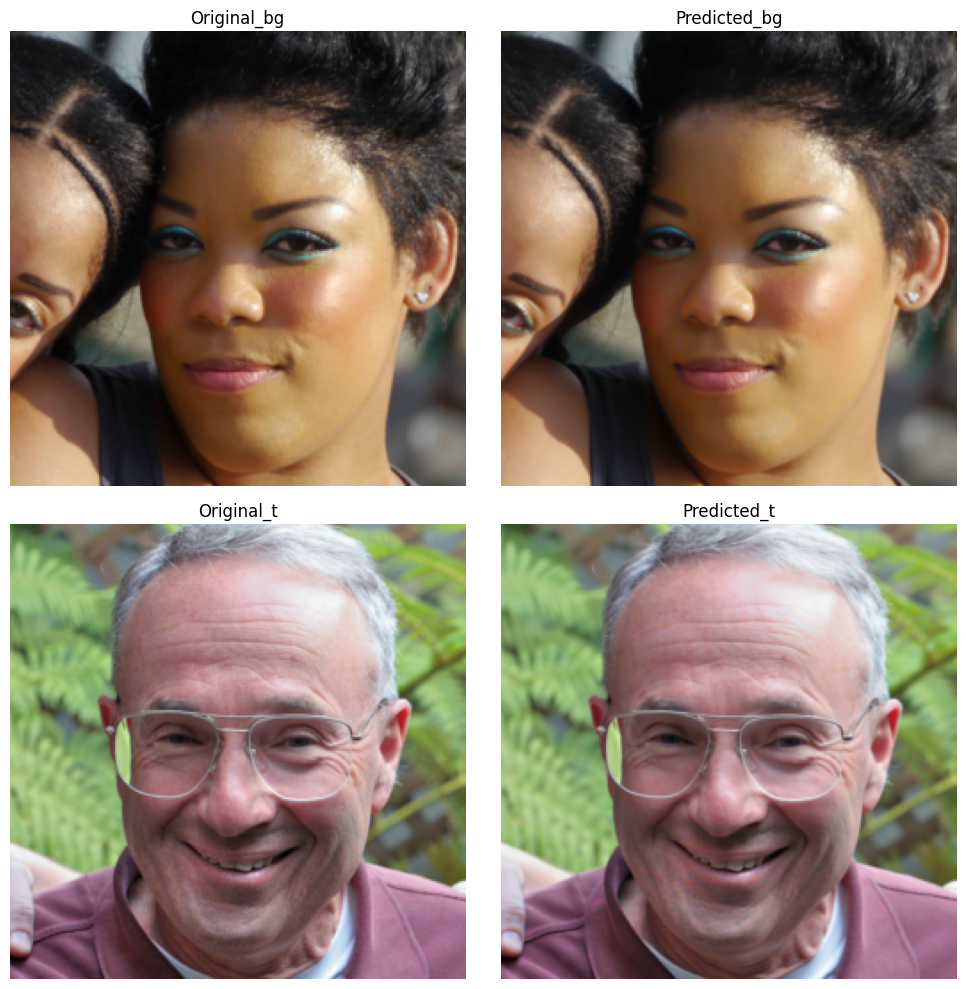

In [30]:
show_image_results(ori_img_bg, ori_img_t, diffAE_zbg, diffAE_zt, xT_bg, xT_t)

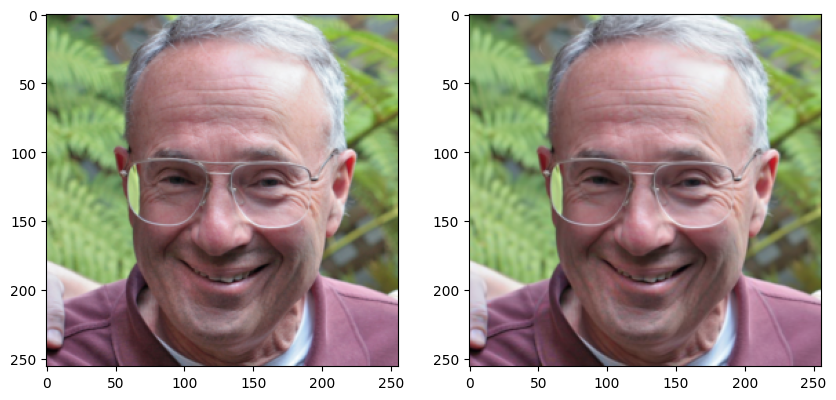

In [15]:
pred = model.render(xT_t, diff_Z_t, T=200)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ori = (ori_img_t + 1) / 2
ax[0].imshow(ori[0].permute(1, 2, 0).cpu())
ax[1].imshow(pred[0].permute(1, 2, 0).cpu())

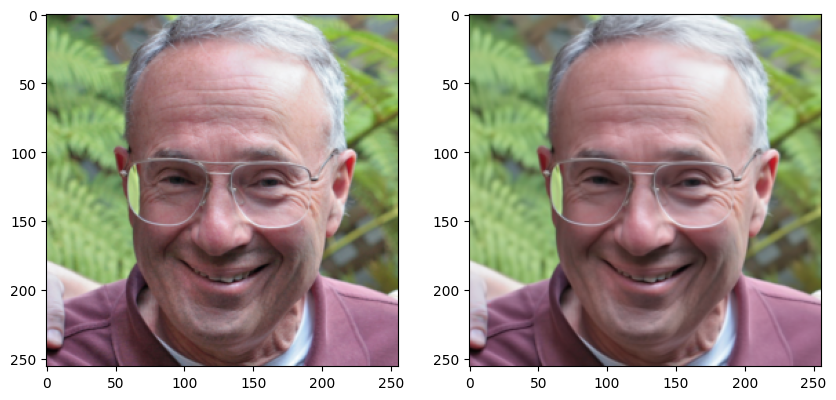

In [14]:
pred = model.render(xT_t, diff_Z_t, T=50)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ori = (ori_img_t + 1) / 2
ax[0].imshow(ori[0].permute(1, 2, 0).cpu())
ax[1].imshow(pred[0].permute(1, 2, 0).cpu())